In [1]:
import numpy as np
from libow8 import sensor_net
import matplotlib.pyplot as plt
import owutils as ut
from designs_diag import designs, align_receiver_to_transmitter
from panel_ow import Panel

In [2]:
import numpy as np
import cma
import sys
import multiprocessing as mp

# ==========================================
# 1. GLOBAL SETUP & PARAMETERS
# ==========================================


KEY = 'C'
params_d = designs[KEY]
params_amb = designs['C'].copy()
params_amb['r_master'] = params_d['r_lights']
params_amb['PT_master'] = params_d['PT_lights']

# ==========================================
# 2. WORKER FUNCTION FOR MULTIPROCESSING
# ==========================================
def optimize_single_sensor(args):
    """
    Worker function to optimize a single sensor. 
    Runs entirely in its own process memory space.
    """
    sensor_idx, r_sens, nS_sens, p_d, p_amb = args
    
    
    state = {
        'h_ww': None,
        'h_amb': None
    }

    
    def sensor_ar_vectorized(x_pop):
        n_particles = x_pop.shape[0]
        theta = x_pop[:, 0]
        phi   = x_pop[:, 1]
        area  = x_pop[:, 2]

        r_sensor = np.tile(r_sens, (n_particles, 1))
        nS_sensor = nS_sens 
        nR = ut.spher_to_cart_ar(1, theta, phi).T

        
        local_p_amb = p_amb.copy()
        local_p_d = p_d.copy()

        local_p_amb['r_sensor'] = r_sensor
        local_p_amb['nR_sensor'] = nR
        local_p_amb['A_sensor'] = area   
        local_p_amb['nS_sensor'] = nS_sensor    

        local_p_d['r_sensor'] = r_sensor
        local_p_d['nR_sensor'] = nR
        local_p_d['A_sensor'] = area    
        local_p_d['nS_sensor'] = nS_sensor   
        
        # Ambient 
        l_amb = sensor_net(**local_p_amb) 
        l_amb.calch(h_ww=state['h_amb'])
        l_amb.light_sim()
        if state['h_amb'] is None: 
            state['h_amb'] = l_amb.h_ww
        
        # Signal 
        l = sensor_net(**local_p_d) 
        l.calch(h_ww=state['h_ww'])
        l.light_sim()
        if state['h_ww'] is None:
            state['h_ww'] = l.h_ww        
        
        l.calc_noise() 
        l.calc_rq() 

        p_all = np.sum(np.sum(l_amb.Pin_sm_diff, axis=0), axis=1) + np.sum(l_amb.Pin_sm, axis=0) + l_amb.Pin_sa + 0.5*l.Pin_sm_tot.flatten()
        G_ac = l.Pin_sm_tot.flatten() / area
        G_all = p_all / area
        
        snr_dB = np.zeros(n_particles)
        e_day = np.zeros(n_particles)
        bitrates = np.zeros(n_particles) 
        
        freq = np.linspace(100, 20000, 50)

        for i in range(n_particles):
            p = Panel(area[i]*1e4, rs=1, rsh=1000, n=1.6, voc=0.64, isc=35e-3, G=G_all[i], Gac=G_ac[i])
            p.run(False)
            
            ind = int(p.ind)
            p.calc_capacitance()
            p.set_circuit(Rc=10, Lo=100e-6, Co=1000e-6)
            p.find_bw()
            
            p.tf(freq)
            p.all_thermal_noise(freq)
            p.shot_noise(freq)
            p.vp2p(freq)
            
            sig = p.vac[ind]
            noise = 4 * (p.th_noise[ind] + p.sh_noise[ind])
            
            if noise <= 1e-20 or sig <= 1e-20:
                snr_dB[i] = -100.0
            else:
                snr_dB[i] = 10 * np.log10( (sig**2) / noise )
            
            e_day[i] = p.Pmax * 3600 * 8 * 0.8
            bitrates[i] = np.floor(p.BW[ind]) * 0.4
        
        l.calc_tbattery(br=bitrates)

        V = 3.3
        cycle_p = np.array([c.calc_cycle_consumption() for c in l.cycles]) * V
        day_s = 3600 * 24
        cycles_day = day_s / l.Tcycle
        e_day_c = cycles_day * cycle_p

        penalty = np.zeros(n_particles)
        
        mask_snr = snr_dB < 8.5
        penalty[mask_snr] += (8.5 - snr_dB[mask_snr]) * 10000
        
        mask_eng = e_day < e_day_c
        penalty[mask_eng] += (e_day_c[mask_eng] - e_day[mask_eng]) * 10000
        
        return area + penalty

    
    def fit_function_batch(x_norm_batch):
        theta = x_norm_batch[:,0] * (np.pi/2)
        phi   = x_norm_batch[:,1] * (2*np.pi)
        area  = 0.001 + x_norm_batch[:,2] * (0.052 - 0.001)
        x_denorm = np.column_stack((theta, phi, area))
        return sensor_ar_vectorized(x_denorm)

    # --- CMA-ES Execution ---
    print(f"[Process Started] Sensor {sensor_idx} at {r_sens}...")
    sys.stdout.flush()

    es = cma.CMAEvolutionStrategy(3 * [0.5], 0.25, {
        'bounds': [0, 1], 
        'popsize': 80, 
        'verbose': -9, 
        'maxiter': 80
    })
    
    while not es.stop():
        solutions = es.ask()
        X_batch = np.array(solutions)
        fitness_values = fit_function_batch(X_batch)
        es.tell(solutions, fitness_values)
        
    best_x_norm = es.result.xbest
    theta = best_x_norm[0] * (np.pi/2)
    phi   = best_x_norm[1] * (2*np.pi)
    area  = 0.001 + best_x_norm[2] * (0.052 - 0.001)
    final_cost = es.result.fbest
    
    print(f"[Process Finished] Sensor {sensor_idx} -> Area={area*1e4:.2f} cm2 | Cost={final_cost:.4f}")
    sys.stdout.flush()

    return {
        'pos': r_sens,
        'theta': np.degrees(theta),
        'phi': np.degrees(phi),
        'area_cm2': area * 1e4,
        'cost': final_cost
    }

# ==========================================
# 3. MAIN EXECUTION BLOCK (MULTIPROCESSING)
# ==========================================

if __name__ == '__main__':
    r_sen_list = designs[KEY]['r_sensor']
    nS_sen_list = np.round(align_receiver_to_transmitter(r_sen_list, np.array([4,0.5,4])), 2)
    N_sensors = r_sen_list.shape[0]

    print(f"Starting Vectorized CMA-ES for {N_sensors} sensors on 4 Processors...")
    
    # Package the arguments for each sensor to pass to the pool
    tasks = []
    for i in range(N_sensors):
        # We pass a copy of params to prevent any dict mutation conflicts
        tasks.append((i+1, r_sen_list[i], nS_sen_list[i], params_d.copy(), params_amb.copy()))

    # Initialize a pool with 4 processors
    with mp.Pool(processes=4) as pool:
        cma_simple_C = pool.map(optimize_single_sensor, tasks)

    # ==========================================
    # 4. SAVE RESULTS TO .NPY
    # ==========================================

    results_array = np.array(cma_simple_C)
    
    # Save to disk
    filename = 'cma_simple_C_eight.npy'
    np.save(filename, results_array)
    
    print("-" * 60)
    print("Optimization Complete.")
    print(f"Results successfully saved to '{filename}'.")
    

Starting Vectorized CMA-ES for 14 sensors on 4 Processors...
[Process Started] Sensor 2 at [1.46666667 0.1        1.        ]...[Process Started] Sensor 1 at [0.2 0.1 1. ]...[Process Started] Sensor 3 at [2.73333333 0.1        1.        ]...

[Process Started] Sensor 4 at [4.  0.1 1. ]...



/home/alexandros/Επιφάνεια εργασίας/eh-ow-main (x)/eh-ow-main_8/libow8.py:42: RuntimeWarning: invalid value encountered in divide
  self.un_n1 = self.dr1 / self.abs_dr1
/home/alexandros/Επιφάνεια εργασίας/eh-ow-main (x)/eh-ow-main_8/libow8.py:43: RuntimeWarning: invalid value encountered in divide
  self.un_n2 = self.dr2 / self.abs_dr2
/home/alexandros/Επιφάνεια εργασίας/eh-ow-main (x)/eh-ow-main_8/libow8.py:42: RuntimeWarning: invalid value encountered in divide
  self.un_n1 = self.dr1 / self.abs_dr1
/home/alexandros/Επιφάνεια εργασίας/eh-ow-main (x)/eh-ow-main_8/libow8.py:42: RuntimeWarning: invalid value encountered in divide
  self.un_n1 = self.dr1 / self.abs_dr1
/home/alexandros/Επιφάνεια εργασίας/eh-ow-main (x)/eh-ow-main_8/libow8.py:43: RuntimeWarning: invalid value encountered in divide
  self.un_n2 = self.dr2 / self.abs_dr2
/home/alexandros/Επιφάνεια εργασίας/eh-ow-main (x)/eh-ow-main_8/libow8.py:43: RuntimeWarning: invalid value encountered in divide
  self.un_n2 = self.dr2 /

[Process Finished] Sensor 2 -> Area=98.34 cm2 | Cost=0.0098
[Process Started] Sensor 5 at [5.26666667 0.1        1.        ]...
[Process Finished] Sensor 3 -> Area=76.87 cm2 | Cost=0.0077
[Process Started] Sensor 6 at [6.53333333 0.1        1.        ]...
[Process Finished] Sensor 1 -> Area=171.64 cm2 | Cost=0.0172
[Process Started] Sensor 7 at [7.8 0.1 1. ]...
[Process Finished] Sensor 4 -> Area=70.91 cm2 | Cost=0.0071
[Process Started] Sensor 8 at [0.2 0.1 3. ]...
[Process Finished] Sensor 5 -> Area=76.87 cm2 | Cost=0.0077
[Process Started] Sensor 9 at [1.46666667 0.1        3.        ]...
[Process Finished] Sensor 7 -> Area=171.64 cm2 | Cost=0.0172
[Process Started] Sensor 10 at [2.73333333 0.1        3.        ]...
[Process Finished] Sensor 6 -> Area=98.34 cm2 | Cost=0.0098
[Process Started] Sensor 11 at [4.  0.1 3. ]...
[Process Finished] Sensor 8 -> Area=47.84 cm2 | Cost=0.0048
[Process Started] Sensor 12 at [5.26666667 0.1        3.        ]...
[Process Finished] Sensor 9 -> Are

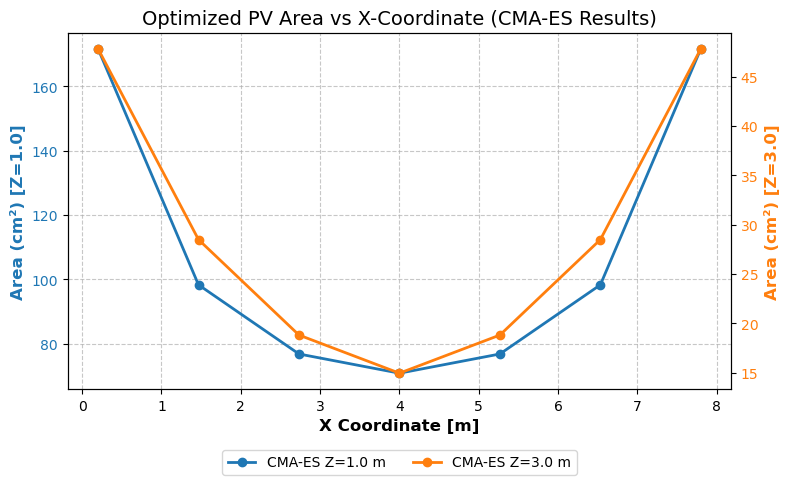

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load CMA-ES results
results = np.load('cma_simple_C_eight.npy', allow_pickle=True)

# 2. Extract X, Z coordinates, and optimized areas
x_coords = np.array([res['pos'][0] for res in results])
z_coords = np.array([res['pos'][2] for res in results])
areas = np.array([res['area_cm2'] for res in results])

# Get unique heights (Z)
unique_zs = np.unique(z_coords)

# 3. Create a single figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

colors = ['tab:blue', 'tab:orange']
axes = [ax1]

# If there are two heights, create a secondary Y-axis
if len(unique_zs) > 1:
    ax2 = ax1.twinx()
    axes.append(ax2)

for i, z_val in enumerate(unique_zs):
    mask = (z_coords == z_val)
    x_z = x_coords[mask]
    areas_z = areas[mask]

    # Sort by X-coordinate
    sort_idx = np.argsort(x_z)
    x_sorted = x_z[sort_idx]
    areas_sorted = areas_z[sort_idx]

    current_ax = axes[i % len(axes)]
    color = colors[i % len(colors)]

    # Plot the line
    current_ax.plot(x_sorted, areas_sorted, marker='o', linestyle='-', color=color, linewidth=2,
                    label=f'CMA-ES Z={z_val} m')

    # Format the Y-axis
    current_ax.set_ylabel(f'Area (cm²) [Z={z_val}]', color=color, fontsize=12, fontweight='bold')
    current_ax.tick_params(axis='y', labelcolor=color)

# 4. Formatting shared X-axis and legend
ax1.set_xlabel('X Coordinate [m]', fontsize=12, fontweight='bold')
plt.title('Optimized PV Area vs X-Coordinate (CMA-ES Results)', fontsize=14)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
if len(axes) > 1:
    lines_2, labels_2 = axes[1].get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2,
               loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
else:
    ax1.legend(loc='best')

ax1.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()